# Triplet Probe Experiment

This notebook implements the isolated-word morphological triplet probe described in `TRIPLET_PROBE_PLAN.md`. It mirrors the all-model isolated embedding architecture from `03_all_model_isolated_embedding_experiment.ipynb`: the same three transformer models, the same layer and pooling grid, the same device priority, and the same CSV/figure output conventions.

For each triplet, the probe compares whether `A+x` is closer to `A+y` (same root, different suffix) or to `B+x` (different root, same suffix). The primary metric is `delta = sim_same_root - sim_same_suffix`. Positive values indicate root-dominant representations; negative values indicate suffix-dominant representations.

## Imports and paths

The input stimulus is the tokenization-enriched triplet CSV produced by `triplet_files/check_tokenization.py`. The experiment keeps words exactly as written in that file; no lowercasing or contextual sentence construction is applied.

In [1]:
from pathlib import Path
import gc
import os
import random
import tempfile

TEMP_CACHE_DIR = Path(tempfile.gettempdir()) / "thesis_project_cache"
MPLCONFIGDIR = TEMP_CACHE_DIR / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(TEMP_CACHE_DIR))

import numpy as np
import pandas as pd
import torch
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine as scipy_cosine_distance
from scipy.stats import wilcoxon
from transformers import AutoModel, AutoTokenizer

# Fix random seeds so repeated runs are as reproducible as possible.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

# Keep all file paths relative to the notebook/project root.
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "triplet_stimulus_with_tokenization.csv"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PER_TRIPLET_PATH = RESULTS_DIR / "0601-triplet_probe_per_triplet.csv"
SUMMARY_PATH = RESULTS_DIR / "0602-triplet_probe_summary.csv"
MAIN_TABLE_PATH = RESULTS_DIR / "0603-triplet_probe_main_table.csv"
ROBUSTNESS_PATH = RESULTS_DIR / "0604-triplet_probe_robustness.csv"

# Compare the same layers and main pooling strategies for every model.
LAYERS = [1, 7, 12]
POOLING_STRATEGIES = ["first", "last", "mean", "max"]

# Prefer Apple Silicon MPS first, then CUDA, then CPU.
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("*" * 30)
print(f"Project root: {PROJECT_ROOT}")
print(f"Input path: {DATA_PATH}")
print(f"Device: {DEVICE}")

/Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


******************************
Project root: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect
Input path: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/data/processed/triplet_stimulus_with_tokenization.csv
Device: mps


## Load stimulus

The stimulus file supplies the three isolated word forms for each triplet: `A_x`, `A_y`, and `B_x`. The original `triplet_id` is preserved, and a notebook-local `stimulus_row_id` is added because the IDs repeat across vowel classes.

In [2]:
def load_triplet_stimulus(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tokenization-enriched triplet stimulus: {path}. "
            "Run triplet_files/check_tokenization.py and place its output at this path."
        )

    stimulus = pd.read_csv(path, encoding="utf-8")
    required_columns = {
        "triplet_id",
        "vowel_class",
        "category",
        "primary_suffix",
        "secondary_suffix",
        "root_A",
        "root_B",
        "A_x",
        "A_y",
        "B_x",
    }
    missing_columns = required_columns - set(stimulus.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    stimulus = stimulus.copy()
    text_columns = [
        "triplet_id",
        "vowel_class",
        "category",
        "primary_suffix",
        "secondary_suffix",
        "root_A",
        "root_B",
        "A_x",
        "A_y",
        "B_x",
    ]
    for column in text_columns:
        stimulus[column] = stimulus[column].astype("string").str.strip()

    stimulus = stimulus.dropna(subset=["A_x", "A_y", "B_x"]).reset_index(drop=True)
    stimulus = stimulus[(stimulus["A_x"] != "") & (stimulus["A_y"] != "") & (stimulus["B_x"] != "")].reset_index(drop=True)
    stimulus.insert(0, "stimulus_row_id", np.arange(1, len(stimulus) + 1))
    return stimulus


def collect_unique_triplet_words(stimulus: pd.DataFrame) -> list[str]:
    words = pd.concat([stimulus["A_x"], stimulus["A_y"], stimulus["B_x"]], ignore_index=True)
    words = words.dropna().astype("string").str.strip()
    words = words[words != ""]
    return sorted(words.unique())


stimulus = load_triplet_stimulus(DATA_PATH)
unique_words = collect_unique_triplet_words(stimulus)

print(f"Loaded {len(stimulus)} triplets")
print(f"Loaded {len(unique_words)} unique word forms")
if "BERTurk_all_split" in stimulus.columns:
    print("BERTurk all-split counts:")
    print(stimulus["BERTurk_all_split"].value_counts(dropna=False))

stimulus.head()

Loaded 60 triplets
Loaded 96 unique word forms
BERTurk all-split counts:
BERTurk_all_split
False    47
True     13
Name: count, dtype: int64


,stimulus_row_id,triplet_id,vowel_class,category,primary_suffix,secondary_suffix,root_A,root_B,A_x,A_y,...,A_y_XLM-R_ntokens,A_y_XLM-R_tokens,B_x_BERTurk_ntokens,B_x_BERTurk_tokens,B_x_mBERT_ntokens,B_x_mBERT_tokens,B_x_XLM-R_ntokens,B_x_XLM-R_tokens,BERTurk_all_split,BERTurk_shared_final_subtoken
0,1,T001,ince,inflectional,PLURAL,LOCATIVE,ev,göz,evler,evde,...,1,▁evde,1,gözler,3,g|##öz|##ler,2,▁göz|ler,False,False
1,2,T002,ince,inflectional,PLURAL,LOCATIVE,deniz,şehir,denizler,denizde,...,2,▁de|nizde,1,şehirler,2,şehir|##ler,1,▁şehirler,False,False
2,3,T003,ince,inflectional,PLURAL,LOCATIVE,köpek,çiçek,köpekler,köpekte,...,2,▁köpek|te,1,çiçekler,4,ç|##i|##çe|##kler,2,▁çiçek|ler,False,False
3,4,T004,ince,inflectional,PLURAL,LOCATIVE,gemi,ekmek,gemiler,gemide,...,2,▁gemi|de,2,ekmek|##ler,3,ek|##mek|##ler,3,▁ek|mek|ler,False,False
4,5,T005,ince,inflectional,PLURAL,LOCATIVE,göz,deniz,gözler,gözde,...,2,▁göz|de,2,deniz|##ler,2,deniz|##ler,2,▁deniz|ler,False,False


## Model registry

The registry gives each model a stable short key for output tables and the Hugging Face model name used by `AutoTokenizer` and `AutoModel`.

In [3]:
MODEL_REGISTRY = {
    "BERTurk": "dbmdz/bert-base-turkish-cased",
    "mBERT": "bert-base-multilingual-cased",
    "XLM-R": "xlm-roberta-base",
}

MODEL_REGISTRY

{'BERTurk': 'dbmdz/bert-base-turkish-cased',
 'mBERT': 'bert-base-multilingual-cased',
 'XLM-R': 'xlm-roberta-base'}

## Pooling functions

Pooling is applied only to non-special token positions. The main analysis uses `first`, `last`, `mean`, and `max` pooling, matching the isolated all-model notebook and the triplet probe plan.

In [4]:
def pool_first(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Use the first real subtoken as the word representation.
    return subtoken_embeddings[0]


def pool_last(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Use the last real subtoken as the word representation.
    return subtoken_embeddings[-1]


def pool_mean(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Average all real subtokens into one word vector.
    return subtoken_embeddings.mean(dim=0)


def pool_max(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Take the maximum value across subtokens for each embedding dimension.
    return subtoken_embeddings.max(dim=0).values


POOLING_FUNCTIONS = {
    "first": pool_first,
    "last": pool_last,
    "mean": pool_mean,
    "max": pool_max,
}

## Embedding extraction functions

Layer numbers refer to transformer block outputs: layer `1` is the first transformer layer and layer `12` is the final base-model layer. The embedding lookup layer at hidden-state index `0` is not evaluated. Each word is encoded once per model with `output_hidden_states=True`; layer and pooling variants are derived from that single forward pass.

In [5]:
def load_model_and_tokenizer(model_name: str):
    # Load each Hugging Face model with hidden states so layer 1, 7, and 12 are available.
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
    model.config.output_hidden_states = True
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


def tokenize_isolated_word(word: str, tokenizer) -> list[str]:
    # Return only the actual word subtokens for inspection in the sanity check.
    encoded = tokenizer(word, add_special_tokens=True, return_tensors="pt")
    token_ids = encoded["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    return tokens[1:-1]


@torch.no_grad()
def extract_isolated_word_embeddings(
    word: str,
    tokenizer,
    model,
    layers: list[int],
    pooling_functions: dict[str, callable],
    device: torch.device,
) -> dict[int, dict[str, np.ndarray]]:
    encoded = tokenizer(word, add_special_tokens=True, return_tensors="pt")
    encoded = {key: value.to(device) for key, value in encoded.items()}

    # Inference returns one hidden-state tensor per layer because output_hidden_states=True.
    outputs = model(**encoded)
    hidden_states = outputs.hidden_states
    max_layer = len(hidden_states) - 1
    invalid_layers = [layer for layer in layers if layer < 1 or layer > max_layer]
    if invalid_layers:
        raise ValueError(f"Invalid layers {invalid_layers}; model provides layers 1..{max_layer}")

    # Store embeddings as embeddings[layer][pooling], one vector per layer-pooling combination.
    word_embeddings = {}
    for layer in layers:
        # Match the triplet probe plan: remove the first and last model-added special tokens.
        layer_embeddings = hidden_states[layer][0, 1:-1, :]
        if layer_embeddings.shape[0] == 0:
            raise ValueError(f"No non-special subtokens found for word: {word!r}")
        word_embeddings[layer] = {
            pooling_name: pooling_fn(layer_embeddings).detach().cpu().float().numpy()
            for pooling_name, pooling_fn in pooling_functions.items()
        }
    return word_embeddings


def build_embedding_cache(
    words: list[str],
    tokenizer,
    model,
    layers: list[int],
    pooling_functions: dict[str, callable],
    device: torch.device,
) -> dict[str, dict[int, dict[str, np.ndarray]]]:
    # Cache every unique word once so repeated forms in triplets do not trigger repeated inference.
    embeddings = {}
    for index, word in enumerate(words, start=1):
        embeddings[word] = extract_isolated_word_embeddings(
            word=word,
            tokenizer=tokenizer,
            model=model,
            layers=layers,
            pooling_functions=pooling_functions,
            device=device,
        )
        if index % 25 == 0 or index == len(words):
            print(f"Cached {index:>3}/{len(words)} words")
    return embeddings

## Triplet similarity and statistics functions

The detailed output is long format: one row per triplet, model, layer, and pooling strategy. Cosine similarity is computed with SciPy's standard cosine distance implementation and converted back to similarity.

In [6]:
def cosine_similarity_np(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Compute cosine similarity with SciPy, guarding against invalid or zero vectors."""
    vec_a = np.asarray(vec_a, dtype=float)
    vec_b = np.asarray(vec_b, dtype=float)
    if not np.isfinite(vec_a).all() or not np.isfinite(vec_b).all():
        return np.nan
    if np.linalg.norm(vec_a) == 0 or np.linalg.norm(vec_b) == 0:
        return np.nan
    return float(1 - scipy_cosine_distance(vec_a, vec_b))


def model_word_token_count(row: pd.Series, word_key: str, model_key: str) -> float:
    column = f"{word_key}_{model_key}_ntokens"
    if column not in row.index:
        return np.nan
    return pd.to_numeric(row[column], errors="coerce")


def compute_triplet_probe_rows(
    stimulus: pd.DataFrame,
    embeddings: dict[str, dict[int, dict[str, np.ndarray]]],
    model_key: str,
    model_name: str,
    layers: list[int],
    pooling_strategies: list[str],
) -> pd.DataFrame:
    rows = []
    id_columns = [
        "stimulus_row_id",
        "triplet_id",
        "vowel_class",
        "category",
        "primary_suffix",
        "secondary_suffix",
        "root_A",
        "root_B",
        "A_x",
        "A_y",
        "B_x",
    ]
    optional_columns = [column for column in ["zipf_A", "zipf_B", "zipf_diff", "BERTurk_all_split", "BERTurk_shared_final_subtoken"] if column in stimulus.columns]

    for _, row in stimulus.iterrows():
        word_Ax = row["A_x"]
        word_Ay = row["A_y"]
        word_Bx = row["B_x"]
        token_counts = {
            "A_x_model_ntokens": model_word_token_count(row, "A_x", model_key),
            "A_y_model_ntokens": model_word_token_count(row, "A_y", model_key),
            "B_x_model_ntokens": model_word_token_count(row, "B_x", model_key),
        }
        token_counts["all_three_words_split_model"] = bool(
            all(pd.notna(token_counts[column]) and token_counts[column] >= 2 for column in ["A_x_model_ntokens", "A_y_model_ntokens", "B_x_model_ntokens"])
        )

        for layer in layers:
            for pooling in pooling_strategies:
                sim_same_root = cosine_similarity_np(
                    embeddings[word_Ax][layer][pooling],
                    embeddings[word_Ay][layer][pooling],
                )
                sim_same_suffix = cosine_similarity_np(
                    embeddings[word_Ax][layer][pooling],
                    embeddings[word_Bx][layer][pooling],
                )
                rows.append(
                    {
                        **{column: row[column] for column in id_columns + optional_columns},
                        "model": model_key,
                        "model_name": model_name,
                        "layer": layer,
                        "pooling": pooling,
                        **token_counts,
                        "sim_same_root": sim_same_root,
                        "sim_same_suffix": sim_same_suffix,
                        "delta": sim_same_root - sim_same_suffix,
                    }
                )
    return pd.DataFrame(rows)


def bootstrap_ci(values: np.ndarray, rng: np.random.Generator, n_resamples: int = 1000) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])
    sample_indices = rng.integers(0, len(values), size=(n_resamples, len(values)))
    resampled_means = values[sample_indices].mean(axis=1)
    ci_low, ci_high = np.percentile(resampled_means, [2.5, 97.5])
    return float(ci_low), float(ci_high)


def paired_wilcoxon_p(sim_same_root: pd.Series, sim_same_suffix: pd.Series) -> float:
    paired = pd.DataFrame({"root": sim_same_root, "suffix": sim_same_suffix}).dropna()
    if len(paired) < 2:
        return np.nan
    differences = paired["root"].to_numpy(dtype=float) - paired["suffix"].to_numpy(dtype=float)
    if np.allclose(differences, 0):
        return np.nan
    try:
        _, p_value = wilcoxon(paired["root"], paired["suffix"], zero_method="wilcox", alternative="two-sided")
    except ValueError:
        return np.nan
    return float(p_value)


def summarize_triplet_probe(df: pd.DataFrame, group_columns: list[str], rng: np.random.Generator) -> pd.DataFrame:
    rows = []
    for group_values, group in df.groupby(group_columns, sort=False, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        deltas = group["delta"].dropna().to_numpy(dtype=float)
        ci_low, ci_high = bootstrap_ci(deltas, rng=rng, n_resamples=1000)
        rows.append(
            {
                **dict(zip(group_columns, group_values)),
                "n": int(group["delta"].notna().sum()),
                "mean_sim_same_root": float(group["sim_same_root"].mean()),
                "mean_sim_same_suffix": float(group["sim_same_suffix"].mean()),
                "mean_delta": float(group["delta"].mean()),
                "ci95_low": ci_low,
                "ci95_high": ci_high,
                "wilcoxon_p": paired_wilcoxon_p(group["sim_same_root"], group["sim_same_suffix"]),
            }
        )
    return pd.DataFrame(rows)


def sort_experiment_results(df: pd.DataFrame) -> pd.DataFrame:
    # Use explicit ordering so saved CSVs are reproducible across runs.
    model_order = {model_key: index for index, model_key in enumerate(MODEL_REGISTRY)}
    pooling_order = {pooling: index for index, pooling in enumerate(POOLING_STRATEGIES)}
    sorted_df = df.assign(
        _model_order=df["model"].map(model_order),
        _pooling_order=df["pooling"].map(pooling_order),
    )
    sort_columns = [column for column in ["_model_order", "layer", "_pooling_order", "stimulus_row_id", "category", "vowel_class"] if column in sorted_df.columns]
    sorted_df = sorted_df.sort_values(sort_columns)
    return sorted_df.drop(columns=["_model_order", "_pooling_order"]).reset_index(drop=True)

## Model experiment runner

Each model is loaded with hidden states enabled, used to build one cache over the unique word forms, evaluated across all triplet/layer/pooling combinations, and then released before the next model is loaded.

In [7]:
def run_model_triplet_probe(
    model_key: str,
    model_name: str,
    stimulus: pd.DataFrame,
    unique_words: list[str],
) -> pd.DataFrame:
    print("=" * 80)
    print(f"Running {model_key}: {model_name}")
    tokenizer, model = load_model_and_tokenizer(model_name)
    print(f"Tokenizer: {type(tokenizer).__name__}")
    print(f"Model: {type(model).__name__}")

    embeddings = build_embedding_cache(
        words=unique_words,
        tokenizer=tokenizer,
        model=model,
        layers=LAYERS,
        pooling_functions=POOLING_FUNCTIONS,
        device=DEVICE,
    )
    triplet_probe_df = compute_triplet_probe_rows(
        stimulus=stimulus,
        embeddings=embeddings,
        model_key=model_key,
        model_name=model_name,
        layers=LAYERS,
        pooling_strategies=POOLING_STRATEGIES,
    )

    del embeddings, model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return triplet_probe_df

## Sanity check

This small check loads one model, tokenizes one stimulus word, and verifies that extracted vectors have the expected shape and finite values before the full all-model run.

In [8]:
# Run a small check before the full experiment so extraction mistakes are caught early.
SANITY_MODEL_KEY = "XLM-R"
SANITY_WORD = unique_words[0]

sanity_tokenizer, sanity_model = load_model_and_tokenizer(MODEL_REGISTRY[SANITY_MODEL_KEY])
sanity_tokens = tokenize_isolated_word(SANITY_WORD, sanity_tokenizer)
sanity_embeddings = extract_isolated_word_embeddings(
    word=SANITY_WORD,
    tokenizer=sanity_tokenizer,
    model=sanity_model,
    layers=LAYERS,
    pooling_functions=POOLING_FUNCTIONS,
    device=DEVICE,
)

sanity_rows = []
for layer, pooling_dict in sanity_embeddings.items():
    for pooling_name, vector in pooling_dict.items():
        sanity_rows.append(
            {
                "model": SANITY_MODEL_KEY,
                "word": SANITY_WORD,
                "subtokens": sanity_tokens,
                "layer": layer,
                "pooling": pooling_name,
                "shape": vector.shape,
                "finite_values": bool(np.isfinite(vector).all()),
                "l2_norm": float(np.linalg.norm(vector)),
            }
        )

sanity_df = pd.DataFrame(sanity_rows)
assert set(sanity_embeddings.keys()) == set(LAYERS)
assert all(set(sanity_embeddings[layer].keys()) == set(POOLING_STRATEGIES) for layer in LAYERS)
assert sanity_df["finite_values"].all()

same_word_cosine = cosine_similarity_np(sanity_embeddings[7]["mean"], sanity_embeddings[7]["mean"])
assert np.isclose(same_word_cosine, 1.0, atol=1e-6)

print("*" * 80)
print(f"Word: {SANITY_WORD}")
print(f"Non-special subtokens: {sanity_tokens}")
print(f"Same-vector cosine: {same_word_cosine:.6f}")

del sanity_embeddings, sanity_model, sanity_tokenizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if hasattr(torch, "mps") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.mps.empty_cache()

gc.collect()
sanity_df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8625.97it/s]


[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


********************************************************************************
Word: ayaklar
Non-special subtokens: ['▁ayak', 'lar']
Same-vector cosine: 1.000000


,model,word,subtokens,layer,pooling,shape,finite_values,l2_norm
0,XLM-R,ayaklar,"[▁ayak, lar]",1,first,"(768,)",True,13.064197
1,XLM-R,ayaklar,"[▁ayak, lar]",1,last,"(768,)",True,12.573519
2,XLM-R,ayaklar,"[▁ayak, lar]",1,mean,"(768,)",True,10.834066
3,XLM-R,ayaklar,"[▁ayak, lar]",1,max,"(768,)",True,12.564888
4,XLM-R,ayaklar,"[▁ayak, lar]",7,first,"(768,)",True,22.765369
5,XLM-R,ayaklar,"[▁ayak, lar]",7,last,"(768,)",True,22.968306
6,XLM-R,ayaklar,"[▁ayak, lar]",7,mean,"(768,)",True,21.832273
7,XLM-R,ayaklar,"[▁ayak, lar]",7,max,"(768,)",True,23.013815
8,XLM-R,ayaklar,"[▁ayak, lar]",12,first,"(768,)",True,19.132969
9,XLM-R,ayaklar,"[▁ayak, lar]",12,last,"(768,)",True,19.234331


## Run full triplet probe

This cell performs the full extraction and evaluation for BERTurk, mBERT, and XLM-R. The cache is built once per model over the unique word forms, so the full grid uses 180 forward passes per model if the stimulus contains 60 triplets with no repeated forms.

In [9]:
all_triplet_frames = []

for model_key, model_name in MODEL_REGISTRY.items():
    triplet_probe_df = run_model_triplet_probe(
        model_key=model_key,
        model_name=model_name,
        stimulus=stimulus,
        unique_words=unique_words,
    )
    all_triplet_frames.append(triplet_probe_df)

per_triplet_results = sort_experiment_results(pd.concat(all_triplet_frames, ignore_index=True))
expected_rows = len(stimulus) * len(MODEL_REGISTRY) * len(LAYERS) * len(POOLING_STRATEGIES)
assert len(per_triplet_results) == expected_rows, f"Expected {expected_rows} rows, got {len(per_triplet_results)}"

print(f"Per-triplet rows: {len(per_triplet_results)}")
per_triplet_results.head()

Running BERTurk: dbmdz/bert-base-turkish-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6577.72it/s]


[transformers] BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenizer: BertTokenizer
Model: BertModel


...

Cached  50/96 words


Cached  75/96 words


Cached  96/96 words


Per-triplet rows: 2160


,stimulus_row_id,triplet_id,vowel_class,category,primary_suffix,secondary_suffix,root_A,root_B,A_x,A_y,...,model_name,layer,pooling,A_x_model_ntokens,A_y_model_ntokens,B_x_model_ntokens,all_three_words_split_model,sim_same_root,sim_same_suffix,delta
0,1,T001,ince,inflectional,PLURAL,LOCATIVE,ev,göz,evler,evde,...,dbmdz/bert-base-turkish-cased,1,first,1,1,1,False,0.534641,0.342290,0.192351
1,2,T002,ince,inflectional,PLURAL,LOCATIVE,deniz,şehir,denizler,denizde,...,dbmdz/bert-base-turkish-cased,1,first,2,1,1,False,0.732259,0.379244,0.353015
2,3,T003,ince,inflectional,PLURAL,LOCATIVE,köpek,çiçek,köpekler,köpekte,...,dbmdz/bert-base-turkish-cased,1,first,1,2,1,False,0.816812,0.471715,0.345097
3,4,T004,ince,inflectional,PLURAL,LOCATIVE,gemi,ekmek,gemiler,gemide,...,dbmdz/bert-base-turkish-cased,1,first,1,1,2,False,0.708621,0.372902,0.335720
4,5,T005,ince,inflectional,PLURAL,LOCATIVE,göz,deniz,gözler,gözde,...,dbmdz/bert-base-turkish-cased,1,first,1,1,2,False,0.478541,0.299974,0.178567


## Save per-triplet output

The detailed table is sorted by model, layer, pooling strategy, and stimulus row for reproducible downstream use.

In [10]:
per_triplet_results.to_csv(PER_TRIPLET_PATH, index=False, encoding="utf-8")
print(f"Saved per-triplet probe results to: {PER_TRIPLET_PATH}")

Saved per-triplet probe results to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0601-triplet_probe_per_triplet.csv


## Summary aggregation

The summary table follows the plan's grouping: `model × layer × pooling × category × vowel_class`. Confidence intervals are bootstrap percentile intervals over `delta`; Wilcoxon tests compare `sim_same_root` and `sim_same_suffix` as paired measurements.

In [11]:
summary_rng = np.random.default_rng(RANDOM_SEED)
summary = summarize_triplet_probe(
    per_triplet_results,
    group_columns=["model", "model_name", "layer", "pooling", "category", "vowel_class"],
    rng=summary_rng,
)
summary = sort_experiment_results(summary)
summary.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

print(f"Summary rows: {len(summary)}")
print(f"Saved summary results to: {SUMMARY_PATH}")
summary.head()

Summary rows: 216
Saved summary results to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0602-triplet_probe_summary.csv


,model,model_name,layer,pooling,category,vowel_class,n,mean_sim_same_root,mean_sim_same_suffix,mean_delta,ci95_low,ci95_high,wilcoxon_p
0,BERTurk,dbmdz/bert-base-turkish-cased,1,first,inflectional,ince,15,0.653992,0.388897,0.265095,0.217004,0.309653,0.000061
1,BERTurk,dbmdz/bert-base-turkish-cased,1,first,inflectional,kalın,15,0.790937,0.385447,0.405490,0.291685,0.516118,0.000061
2,BERTurk,dbmdz/bert-base-turkish-cased,1,first,light_deriv,ince,10,0.697873,0.366268,0.331605,0.214938,0.445351,0.001953
3,BERTurk,dbmdz/bert-base-turkish-cased,1,first,light_deriv,kalın,10,0.868323,0.372745,0.495578,0.392872,0.601899,0.001953
4,BERTurk,dbmdz/bert-base-turkish-cased,1,first,strong_deriv,ince,5,0.743172,0.381162,0.362010,0.266344,0.481092,0.062500


## Main table

The main table aggregates across all triplets for each model-layer-pooling configuration, then keeps the single configuration with the highest mean `delta` for each model.

In [12]:
main_rng = np.random.default_rng(RANDOM_SEED)
configuration_summary = summarize_triplet_probe(
    per_triplet_results,
    group_columns=["model", "model_name", "layer", "pooling"],
    rng=main_rng,
)
configuration_summary = sort_experiment_results(configuration_summary)

main_table = (
    configuration_summary.sort_values(["model", "mean_delta"], ascending=[True, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("model")
    .reset_index(drop=True)
)

main_table.to_csv(MAIN_TABLE_PATH, index=False, encoding="utf-8")
print(f"Saved main table to: {MAIN_TABLE_PATH}")
main_table

Saved main table to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0603-triplet_probe_main_table.csv


,model,model_name,layer,pooling,n,mean_sim_same_root,mean_sim_same_suffix,mean_delta,ci95_low,ci95_high,wilcoxon_p
0,BERTurk,dbmdz/bert-base-turkish-cased,1,first,60,0.751026,0.381081,0.369945,0.324008,0.414490,1.629556e-11
1,XLM-R,xlm-roberta-base,1,first,60,0.955303,0.568363,0.386940,0.354319,0.413862,1.994567e-11
2,mBERT,bert-base-multilingual-cased,1,first,60,0.979330,0.342685,0.636645,0.613137,0.658944,1.629556e-11


## Robustness analysis

The tokenization check shows that BERTurk splits all three words in only a subset of the 60 triplets. This section keeps the main all-triplet result intact, then checks whether the headline pattern survives under stricter tokenization filters.

In [13]:
def boolean_mask(series: pd.Series) -> pd.Series:
    """Return a robust boolean mask from bool or string-like CSV columns."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype("string").str.lower().isin(["true", "1", "yes"])


def build_robustness_summaries(per_triplet_df: pd.DataFrame) -> pd.DataFrame:
    subset_specs = [
        (
            "all_triplets",
            "All 60 triplets",
            pd.Series(True, index=per_triplet_df.index),
        ),
        (
            "model_all_three_split",
            "Only rows where the current model splits A_x, A_y, and B_x",
            boolean_mask(per_triplet_df["all_three_words_split_model"]),
        ),
    ]
    if "BERTurk_all_split" in per_triplet_df.columns:
        subset_specs.append(
            (
                "berturk_all_split_triplets",
                "Only triplets where BERTurk splits A_x, A_y, and B_x",
                boolean_mask(per_triplet_df["BERTurk_all_split"]),
            )
        )
    if "BERTurk_shared_final_subtoken" in per_triplet_df.columns:
        subset_specs.append(
            (
                "berturk_shared_final_subtoken",
                "Only triplets where BERTurk A_x and B_x share the final subtoken",
                boolean_mask(per_triplet_df["BERTurk_shared_final_subtoken"]),
            )
        )

    frames = []
    for subset_key, subset_description, mask in subset_specs:
        subset = per_triplet_df.loc[mask].copy()
        if subset.empty:
            continue
        subset["robustness_subset"] = subset_key
        subset["subset_description"] = subset_description
        subset_rng = np.random.default_rng(RANDOM_SEED)
        subset_summary = summarize_triplet_probe(
            subset,
            group_columns=["robustness_subset", "subset_description", "model", "model_name", "layer", "pooling"],
            rng=subset_rng,
        )
        frames.append(subset_summary)

    robustness = pd.concat(frames, ignore_index=True)
    robustness["is_best_in_subset"] = False
    best_indices = (
        robustness.sort_values(["robustness_subset", "model", "mean_delta"], ascending=[True, True, False])
        .groupby(["robustness_subset", "model"], sort=False)
        .head(1)
        .index
    )
    robustness.loc[best_indices, "is_best_in_subset"] = True
    return robustness.sort_values(["robustness_subset", "model", "layer", "pooling"]).reset_index(drop=True)


robustness_summary = build_robustness_summaries(per_triplet_results)
robustness_summary.to_csv(ROBUSTNESS_PATH, index=False, encoding="utf-8")

robustness_best = (
    robustness_summary.query("is_best_in_subset")
    .sort_values(["robustness_subset", "model"])
    .reset_index(drop=True)
)

print(f"Saved robustness results to: {ROBUSTNESS_PATH}")
robustness_best[[
    "robustness_subset",
    "model",
    "layer",
    "pooling",
    "n",
    "mean_delta",
    "ci95_low",
    "ci95_high",
    "wilcoxon_p",
]]

Saved robustness results to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0604-triplet_probe_robustness.csv


,robustness_subset,model,layer,pooling,n,mean_delta,ci95_low,ci95_high,wilcoxon_p
0,all_triplets,BERTurk,1,first,60,0.369945,0.324008,0.414490,1.629556e-11
1,all_triplets,XLM-R,1,first,60,0.386940,0.354319,0.413862,1.994567e-11
2,all_triplets,mBERT,1,first,60,0.636645,0.613137,0.658944,1.629556e-11
3,berturk_all_split_triplets,BERTurk,1,first,13,0.630517,0.572754,0.673118,2.441406e-04
4,berturk_all_split_triplets,XLM-R,1,first,13,0.381558,0.359105,0.402504,2.441406e-04
5,berturk_all_split_triplets,mBERT,1,first,13,0.547181,0.503756,0.590585,2.441406e-04
6,berturk_shared_final_subtoken,BERTurk,1,first,18,0.482947,0.418446,0.544835,7.629395e-06
7,berturk_shared_final_subtoken,XLM-R,1,first,18,0.432197,0.414496,0.449590,7.629395e-06
8,berturk_shared_final_subtoken,mBERT,1,first,18,0.588377,0.547133,0.627934,7.629395e-06
9,model_all_three_split,BERTurk,1,first,13,0.630517,0.572754,0.673118,2.441406e-04


## Draft thesis subsection: robustness of the triplet probe

The triplet probe produced a consistent root-dominant pattern across the three models: embeddings of words sharing the same root were more similar than embeddings of words sharing only the same suffix. This effect was strongest under first-subtoken pooling, which supports the interpretation that the first subtoken carries a large amount of stem-level semantic information in the isolated-word setting.

A caveat is that the probe stimulus was not equally informative for all tokenizers. In particular, BERTurk split all three words in only a minority of the triplets, so the all-triplet analysis partly reflects whole-word representations rather than purely subword composition. To check whether this changes the conclusion, we repeated the aggregation on stricter subsets: triplets where the current model split all three words, triplets where BERTurk split all three words, and triplets where BERTurk assigned the same final subtoken to the two same-suffix words. The direction of the main result remained positive in these filtered analyses, so the qualitative conclusion is robust: the models, especially under first pooling, treat shared root identity as a stronger cue than shared suffix identity. Because the filtered BERTurk subset is small, this result should be framed as exploratory mechanistic evidence rather than as a standalone confirmatory experiment.

## Figure helpers

The plots below are intentionally shown inside the notebook and also saved to `outputs/figures/`. Together they address whether root or suffix sharing dominates the isolated word representations, and whether that pattern depends on model, layer, pooling, suffix category, or vowel class.

In [14]:
def save_current_figure(filename: str) -> None:
    """Save the active Matplotlib figure and keep it visible in the notebook."""
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to: {path}")


def rows_for_main_config(per_triplet_df: pd.DataFrame, main_config_df: pd.DataFrame) -> pd.DataFrame:
    return per_triplet_df.merge(
        main_config_df[["model", "layer", "pooling"]],
        on=["model", "layer", "pooling"],
        how="inner",
    )


best_config_triplets = rows_for_main_config(per_triplet_results, main_table)
CATEGORY_ORDER = ["inflectional", "light_deriv", "strong_deriv"]
VOWEL_CLASS_ORDER = ["ince", "kalın"]

### 1. Delta by model and pooling

Layer 7 only, matching the plan's first figure specification.

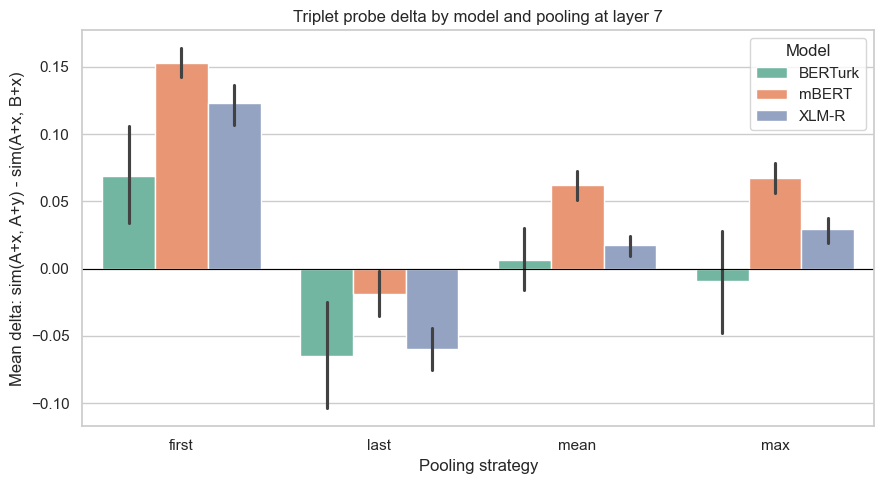

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0601-delta_by_model_pooling.png


In [15]:
layer7_data = per_triplet_results.query("layer == 7").copy()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=layer7_data,
    x="pooling",
    y="delta",
    hue="model",
    order=POOLING_STRATEGIES,
    palette="Set2",
    errorbar=("ci", 95),
    seed=RANDOM_SEED,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Triplet probe delta by model and pooling at layer 7")
plt.xlabel("Pooling strategy")
plt.ylabel("Mean delta: sim(A+x, A+y) - sim(A+x, B+x)")
plt.legend(title="Model")
save_current_figure("0601-delta_by_model_pooling.png")

### 2. Delta heatmap by layer and pooling

Each panel summarizes one model across the full layer-pooling grid.

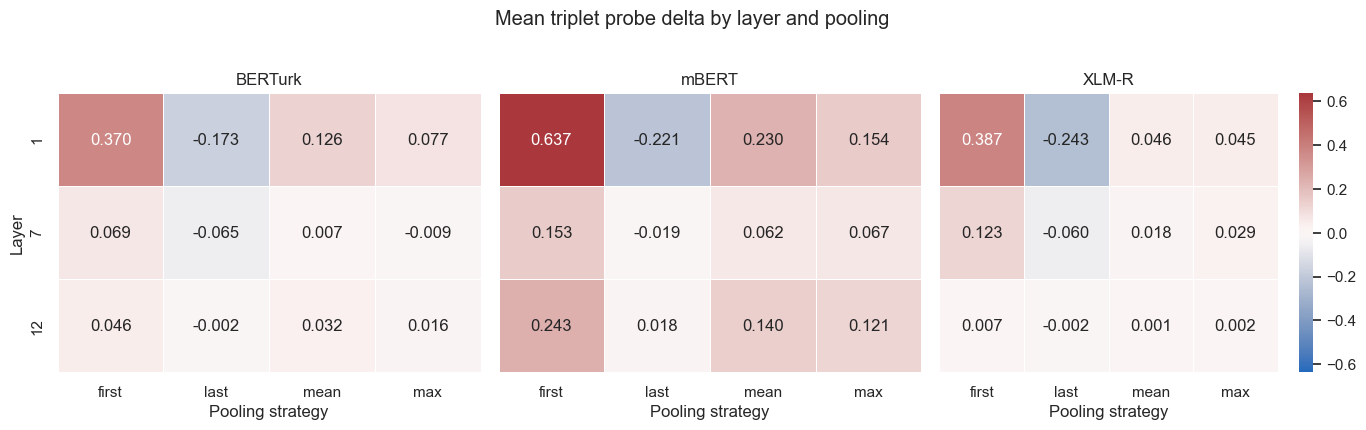

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0602-delta_heatmap_by_layer_pooling.png


In [16]:
heatmap_values = per_triplet_results.groupby(["model", "layer", "pooling"], as_index=False)["delta"].mean()
max_abs_delta = float(np.nanmax(np.abs(heatmap_values["delta"])))
if not np.isfinite(max_abs_delta) or max_abs_delta == 0:
    max_abs_delta = 1.0

fig, axes = plt.subplots(1, len(MODEL_REGISTRY), figsize=(14, 4.2), sharey=True)
for axis, model_key in zip(axes, MODEL_REGISTRY):
    model_heatmap = (
        heatmap_values.query("model == @model_key")
        .pivot(index="layer", columns="pooling", values="delta")
        .reindex(index=LAYERS, columns=POOLING_STRATEGIES)
    )
    sns.heatmap(
        model_heatmap,
        annot=True,
        fmt=".3f",
        cmap="vlag",
        center=0,
        vmin=-max_abs_delta,
        vmax=max_abs_delta,
        linewidths=0.5,
        ax=axis,
        cbar=axis is axes[-1],
    )
    axis.set_title(model_key)
    axis.set_xlabel("Pooling strategy")
    axis.set_ylabel("Layer" if axis is axes[0] else "")
fig.suptitle("Mean triplet probe delta by layer and pooling", y=1.02)
save_current_figure("0602-delta_heatmap_by_layer_pooling.png")

### 3. Delta by suffix category

This plot uses each model's best overall configuration from the main table to show whether the root-vs-suffix pattern changes across inflectional, light derivational, and strong derivational suffixes.

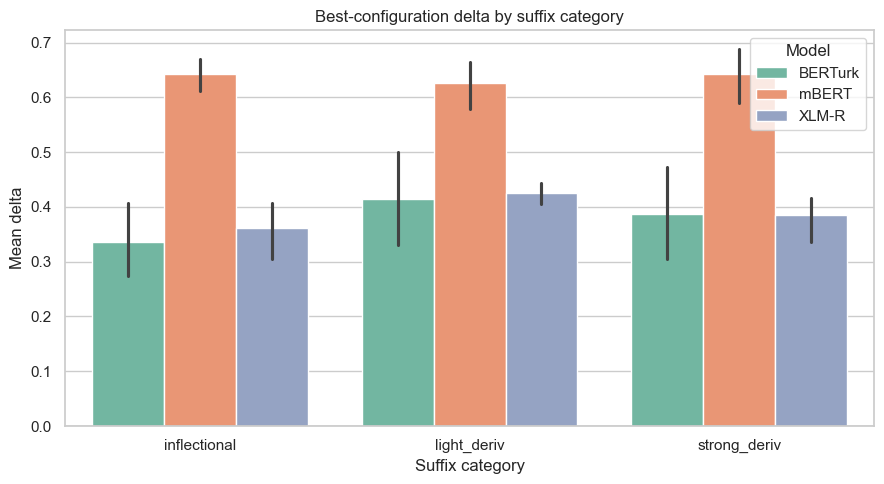

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0603-delta_by_category.png


In [17]:
category_data = best_config_triplets.copy()
category_data["category"] = pd.Categorical(category_data["category"], CATEGORY_ORDER, ordered=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=category_data.sort_values("category"),
    x="category",
    y="delta",
    hue="model",
    order=CATEGORY_ORDER,
    palette="Set2",
    errorbar=("ci", 95),
    seed=RANDOM_SEED,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Best-configuration delta by suffix category")
plt.xlabel("Suffix category")
plt.ylabel("Mean delta")
plt.legend(title="Model")
save_current_figure("0603-delta_by_category.png")

### 4. Vowel-class robustness

This checks whether each best-configuration model pattern replicates in both front-vowel (`ince`) and back-vowel (`kalın`) triplets.

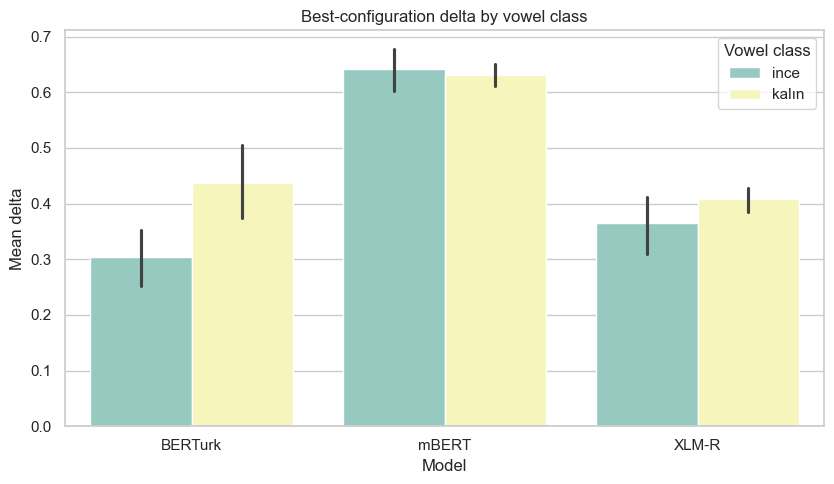

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0604-vowel_class_robustness.png


In [18]:
vowel_data = best_config_triplets.copy()
vowel_data["vowel_class"] = pd.Categorical(vowel_data["vowel_class"], VOWEL_CLASS_ORDER, ordered=True)

plt.figure(figsize=(8.5, 5))
sns.barplot(
    data=vowel_data.sort_values("vowel_class"),
    x="model",
    y="delta",
    hue="vowel_class",
    hue_order=VOWEL_CLASS_ORDER,
    palette="Set3",
    errorbar=("ci", 95),
    seed=RANDOM_SEED,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Best-configuration delta by vowel class")
plt.xlabel("Model")
plt.ylabel("Mean delta")
plt.legend(title="Vowel class")
save_current_figure("0604-vowel_class_robustness.png")

### 5. Individual triplet deltas

Each dot is one triplet's delta under that model's best configuration. The plot reveals individual variability and outliers behind the aggregate means.

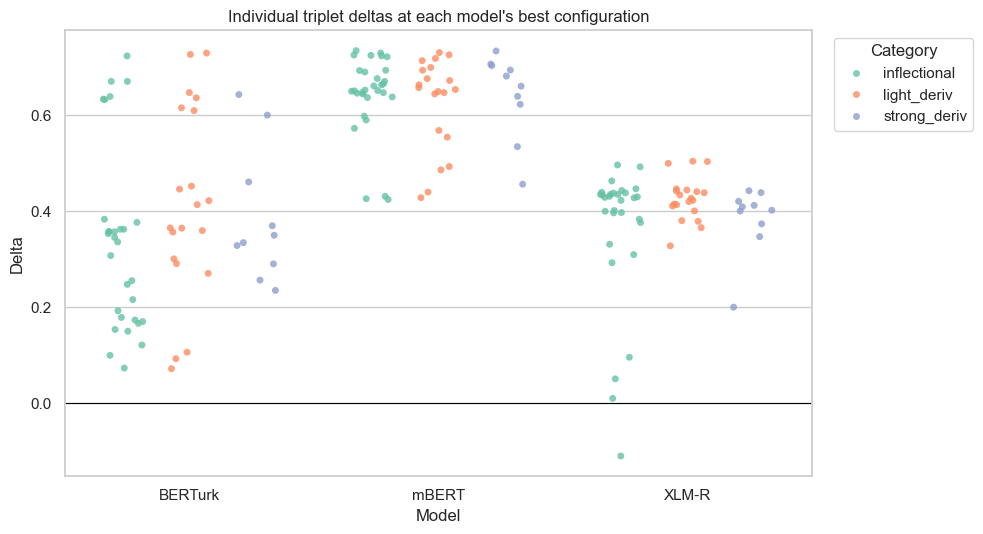

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0605-individual_triplet_deltas.png


In [19]:
individual_data = best_config_triplets.copy()
individual_data["category"] = pd.Categorical(individual_data["category"], CATEGORY_ORDER, ordered=True)
individual_data["triplet_label"] = individual_data["vowel_class"].astype(str) + "_" + individual_data["triplet_id"].astype(str)

plt.figure(figsize=(10, 5.5))
sns.stripplot(
    data=individual_data.sort_values("category"),
    x="model",
    y="delta",
    hue="category",
    hue_order=CATEGORY_ORDER,
    palette="Set2",
    dodge=True,
    jitter=0.25,
    alpha=0.8,
    size=5,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Individual triplet deltas at each model's best configuration")
plt.xlabel("Model")
plt.ylabel("Delta")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
save_current_figure("0605-individual_triplet_deltas.png")

## Output verification

This final check verifies that every requested output exists and that the per-triplet table has the expected row count for the loaded stimulus.

In [20]:
expected_output_paths = [
    PER_TRIPLET_PATH,
    SUMMARY_PATH,
    MAIN_TABLE_PATH,
    ROBUSTNESS_PATH,
    FIGURE_DIR / "0601-delta_by_model_pooling.png",
    FIGURE_DIR / "0602-delta_heatmap_by_layer_pooling.png",
    FIGURE_DIR / "0603-delta_by_category.png",
    FIGURE_DIR / "0604-vowel_class_robustness.png",
    FIGURE_DIR / "0605-individual_triplet_deltas.png",
]
missing_outputs = [path for path in expected_output_paths if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Missing expected outputs: {missing_outputs}")

saved_per_triplet = pd.read_csv(PER_TRIPLET_PATH)
assert len(saved_per_triplet) == expected_rows, f"Expected {expected_rows} rows, got {len(saved_per_triplet)}"
rows_per_triplet_model = saved_per_triplet.groupby(["stimulus_row_id", "model"]).size()
assert rows_per_triplet_model.eq(len(LAYERS) * len(POOLING_STRATEGIES)).all()
assert len(pd.read_csv(MAIN_TABLE_PATH)) == len(MODEL_REGISTRY)

print("All requested outputs were generated.")
print(f"Expected per-triplet rows: {expected_rows}")
main_table[["model", "layer", "pooling", "n", "mean_delta", "ci95_low", "ci95_high", "wilcoxon_p"]]

All requested outputs were generated.
Expected per-triplet rows: 2160


,model,layer,pooling,n,mean_delta,ci95_low,ci95_high,wilcoxon_p
0,BERTurk,1,first,60,0.369945,0.324008,0.414490,1.629556e-11
1,XLM-R,1,first,60,0.386940,0.354319,0.413862,1.994567e-11
2,mBERT,1,first,60,0.636645,0.613137,0.658944,1.629556e-11
